In [1]:
import numpy as np
import scipy.linalg
import sympy as sym
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12
})

np.random.seed(42)
print('NumPy version:', np.__version__)
print('SciPy version:', scipy.__version__)
print('SymPy version:', sym.__version__)
print('Setup complete.')

NumPy version: 2.0.2
SciPy version: 1.16.3
SymPy version: 1.14.0
Setup complete.


**Systems of Equations -> Matrix Equations**

In [2]:
# Solve the textbook system: x + y = 4, -x/2 + y = 2
A = np.array([[ 1,  1],
              [-0.5, 1]])
b = np.array([4, 2])

# Method 1: Matrix inverse
x_inv = np.linalg.inv(A) @ b

# Method 2: np.linalg.solve (uses LU internally — more stable)
x_solve = np.linalg.solve(A, b)

print(f'A =\n{A}')
print(f'b = {b}')
print(f'\nSolution via inverse: x = {x_inv[0]:.4f}, y = {x_inv[1]:.4f}')
print(f'Solution via solve:   x = {x_solve[0]:.4f}, y = {x_solve[1]:.4f}')
print(f'\nVerify A @ x = b: {np.round(A @ x_solve, 10).tolist()}')

A =
[[ 1.   1. ]
 [-0.5  1. ]]
b = [4 2]

Solution via inverse: x = 1.3333, y = 2.6667
Solution via solve:   x = 1.3333, y = 2.6667

Verify A @ x = b: [4.0, 2.0]


In [3]:
# Demonstrate: multiplication order matters
np.random.seed(42)
A = np.random.randn(4, 4)
B = np.random.randn(4, 4)

# Correct: left-multiply
X1 = np.linalg.inv(A) @ B
res1 = A @ X1 - B

# Wrong: right-multiply
X2 = B @ np.linalg.inv(A)
res2 = A @ X2 - B

print(f'Residual (correct, A^(-1)B):  max|res| = {np.max(np.abs(res1)):.2e}')
print(f'Residual (wrong, BA^(-1)):    max|res| = {np.max(np.abs(res2)):.2e}')
print(f'\nCorrect gives zero residual: {np.allclose(res1, 0)}')
print(f'Wrong gives zero residual:   {np.allclose(res2, 0)}')

Residual (correct, A^(-1)B):  max|res| = 8.88e-16
Residual (wrong, BA^(-1)):    max|res| = 9.80e+00

Correct gives zero residual: True
Wrong gives zero residual:   False


**Row Reduction and Echelon Form**

Row reduction transforms a dense matrix into an upper-triangular (echelon) matrix using two operations:

Scalar multiply a row
Add (a multiple of) one row to another

In [4]:
# Textbook 2x2 row reduction example
A2 = np.array([[2, 3],
               [-2, 2]], dtype=float)

# Operation: R1 + R2 (add first row to second)
L_inv_2 = np.array([[1, 0],
                     [1, 1]], dtype=float)

U2 = L_inv_2 @ A2

print(f'A =\n{A2}')
print(f'\nL^(-1) (row operation: R1 + R2) =\n{L_inv_2}')
print(f'\nU = L^(-1) @ A =\n{U2}')
print(f'\nU is upper-triangular: {np.allclose(U2, np.triu(U2))}')

A =
[[ 2.  3.]
 [-2.  2.]]

L^(-1) (row operation: R1 + R2) =
[[1. 0.]
 [1. 1.]]

U = L^(-1) @ A =
[[2. 3.]
 [0. 5.]]

U is upper-triangular: True


In [5]:
# Textbook 3x3 row reduction example: two steps
A3 = np.array([[ 1,  2,  2],
               [-1,  3,  0],
               [ 2,  4, -3]], dtype=float)

print(f'Original A =\n{A3}\n')

# Step 1: R1 + R2 to eliminate A[1,0] = -1
A_step1 = A3.copy()
A_step1[1] = A3[0] + A3[1]  # R1 + R2
print(f'After R1 + R2:\n{A_step1}\n')

# Step 2: -2*R1 + R3 to eliminate A[2,0] = 2
A_step2 = A_step1.copy()
A_step2[2] = -2*A_step1[0] + A_step1[2]  # -2R1 + R3
print(f'After -2R1 + R3 (echelon form U):\n{A_step2}\n')
print(f'Upper-triangular: {np.allclose(A_step2, np.triu(A_step2))}')

Original A =
[[ 1.  2.  2.]
 [-1.  3.  0.]
 [ 2.  4. -3.]]

After R1 + R2:
[[ 1.  2.  2.]
 [ 0.  5.  2.]
 [ 2.  4. -3.]]

After -2R1 + R3 (echelon form U):
[[ 1.  2.  2.]
 [ 0.  5.  2.]
 [ 0.  0. -7.]]

Upper-triangular: True


**Gaussian Elimination**

In [6]:
def gaussian_elimination(A, b):
    """Solve Ax = b via Gaussian elimination + back substitution."""
    n = len(b)
    # Augmented matrix
    Aug = np.hstack([A.astype(float), b.reshape(-1, 1).astype(float)])

    # Forward elimination: row reduce to echelon form
    for col in range(n):
        # Partial pivoting: swap rows for numerical stability
        max_row = np.argmax(np.abs(Aug[col:, col])) + col
        Aug[[col, max_row]] = Aug[[max_row, col]]

        # Eliminate below
        for row in range(col + 1, n):
            factor = Aug[row, col] / Aug[col, col]
            Aug[row] -= factor * Aug[col]

    # Back substitution
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (Aug[i, -1] - Aug[i, i+1:n] @ x[i+1:]) / Aug[i, i]

    return x, Aug

# Solve the textbook system
A = np.array([[ 1,  1],
              [-0.5, 1]])
b = np.array([4, 2])

x_ge, Aug = gaussian_elimination(A, b)

print(f'Augmented matrix after row reduction:')
print(np.round(Aug, 6))
print(f'\nSolution: x = {x_ge[0]:.6f}, y = {x_ge[1]:.6f}')
print(f'\nVerify: {np.round(A @ x_ge, 10).tolist()}')
print(f'Matches np.linalg.solve: {np.allclose(x_ge, np.linalg.solve(A, b))}')

Augmented matrix after row reduction:
[[1.  1.  4. ]
 [0.  1.5 4. ]]

Solution: x = 1.333333, y = 2.666667

Verify: [4.0, 2.0]
Matches np.linalg.solve: True


Our implementation includes partial pivoting (swapping rows so the largest element becomes the pivot), which prevents division by small numbers. This is the same strategy that scipy.linalg.lu uses internally.

In [7]:
# Larger system: 4x4
np.random.seed(42)
A4 = np.random.randn(4, 4)
b4 = np.random.randn(4)

x_ge4, _ = gaussian_elimination(A4, b4)
x_np4 = np.linalg.solve(A4, b4)

print(f'Our Gaussian elimination: {np.round(x_ge4, 8)}')
print(f'np.linalg.solve:          {np.round(x_np4, 8)}')
print(f'Match: {np.allclose(x_ge4, x_np4)}')
print(f'Max residual |Ax - b|: {np.max(np.abs(A4 @ x_ge4 - b4)):.2e}')

Our Gaussian elimination: [ 2.69112629  0.18842227  1.72349387 -2.25851566]
np.linalg.solve:          [ 2.69112629  0.18842227  1.72349387 -2.25851566]
Match: True
Max residual |Ax - b|: 2.78e-16


**Gauss-Jordan Elimination and the RREF**

Gauss-Jordan elimination extends row reduction in two ways:

Scale each pivot to 1
Eliminate upward (not just downward) to zero out all elements above and below each pivot

In [8]:
# RREF via SymPy
A_sys = np.array([[1, 1, 4],
                  [-0.5, 1, 2]])

rref_result, pivots = sym.Matrix(A_sys).rref()
rref_array = np.array(rref_result.tolist(), dtype=float)

print(f'Augmented matrix [A | b]:')
print(A_sys)
print(f'\nRREF:')
print(np.round(rref_array, 6))
print(f'Pivot columns: {pivots}')
print(f'\nSolution: x = {rref_array[0,2]:.6f}, y = {rref_array[1,2]:.6f}')

Augmented matrix [A | b]:
[[ 1.   1.   4. ]
 [-0.5  1.   2. ]]

RREF:
[[1.       0.       1.333333]
 [0.       1.       2.666667]]
Pivot columns: (0, 1)

Solution: x = 1.333333, y = 2.666667


In [9]:
# Compute inverse via RREF of [A | I]
A = np.array([[1, 4],
              [2, 7]], dtype=float)

# Augment A with identity
augmented = np.hstack([A, np.eye(2)])
print(f'Augmented [A | I]:')
print(augmented)

# RREF
rref_result, _ = sym.Matrix(augmented).rref()
rref_arr = np.array(rref_result.tolist(), dtype=float)
print(f'\nRREF [I | A^(-1)]:')
print(rref_arr)

# Extract inverse (right half)
A_inv_rref = rref_arr[:, 2:]
A_inv_numpy = np.linalg.inv(A)

print(f'\nA^(-1) via RREF:\n{A_inv_rref}')
print(f'A^(-1) via NumPy:\n{A_inv_numpy}')
print(f'Match: {np.allclose(A_inv_rref, A_inv_numpy)}')
print(f'\nVerify: A @ A^(-1) =\n{np.round(A @ A_inv_rref, 10)}')

Augmented [A | I]:
[[1. 4. 1. 0.]
 [2. 7. 0. 1.]]

RREF [I | A^(-1)]:
[[ 1.  0. -7.  4.]
 [ 0.  1.  2. -1.]]

A^(-1) via RREF:
[[-7.  4.]
 [ 2. -1.]]
A^(-1) via NumPy:
[[-7.  4.]
 [ 2. -1.]]
Match: True

Verify: A @ A^(-1) =
[[1. 0.]
 [0. 1.]]


This approach computes the inverse without determinants -- it relies entirely on row operations. However, like all inversion methods, it is sensitive to ill-conditioning.

**LU Decomposition**

In [10]:
# Textbook LU example
A = np.array([[2, 2, 4],
              [1, 0, 3],
              [2, 1, 2]], dtype=float)

P, L, U = scipy.linalg.lu(A)

print(f'A =\n{A.astype(int)}')
print(f'\nP (permutation) =\n{P}')
print(f'\nL (lower-triangular, 1s on diagonal) =\n{L}')
print(f'\nU (upper-triangular) =\n{U}')
print(f'\nP @ L @ U =\n{np.round(P @ L @ U, 10)}')
print(f'Matches A: {np.allclose(P @ L @ U, A)}')

# Verify L has 1s on diagonal
print(f'\nL diagonal: {np.diag(L)}')

A =
[[2 2 4]
 [1 0 3]
 [2 1 2]]

P (permutation) =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

L (lower-triangular, 1s on diagonal) =
[[1.  0.  0. ]
 [0.5 1.  0. ]
 [1.  1.  1. ]]

U (upper-triangular) =
[[ 2.  2.  4.]
 [ 0. -1.  1.]
 [ 0.  0. -3.]]

P @ L @ U =
[[2. 2. 4.]
 [1. 0. 3.]
 [2. 1. 2.]]
Matches A: True

L diagonal: [1. 1. 1.]


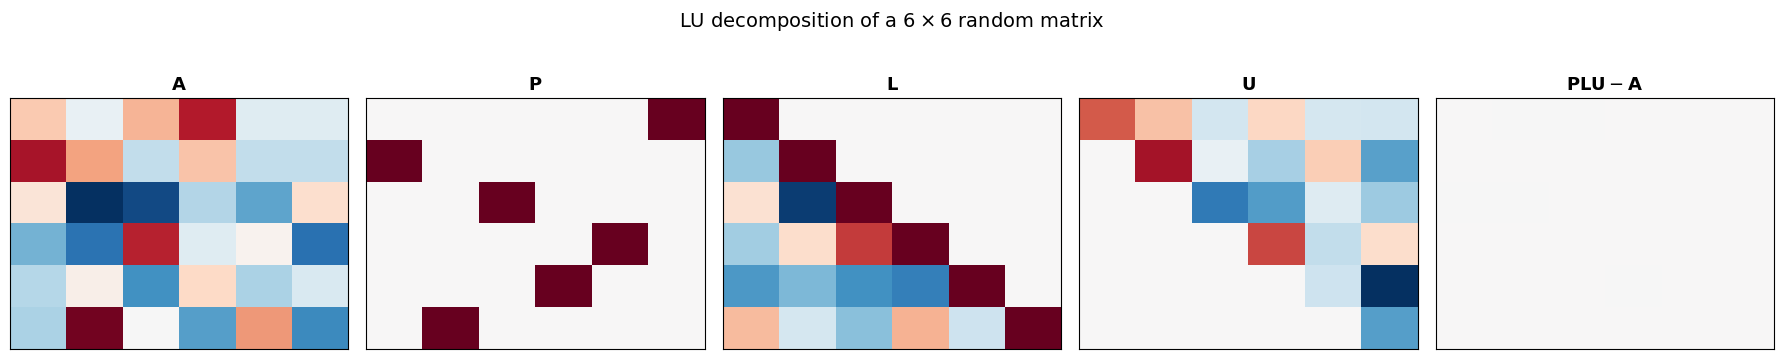

||PLU - A||_F = 5.30e-16
P is orthogonal (P^T P = I): True


In [11]:
# LU of a larger random matrix
np.random.seed(42)
A_big = np.random.randn(6, 6)
P_big, L_big, U_big = scipy.linalg.lu(A_big)

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))

for ax, M, title in zip(axes,
    [A_big, P_big, L_big, U_big, P_big @ L_big @ U_big - A_big],
    ['$\\mathbf{A}$', '$\\mathbf{P}$', '$\\mathbf{L}$',
     '$\\mathbf{U}$', '$\\mathbf{PLU} - \\mathbf{A}$']):
    vmax = max(np.abs(M).max(), 1e-10)
    ax.imshow(M, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_title(title, fontsize=13)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('LU decomposition of a $6 \\times 6$ random matrix', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_lu_decomp.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'||PLU - A||_F = {np.linalg.norm(P_big @ L_big @ U_big - A_big):.2e}')
print(f'P is orthogonal (P^T P = I): {np.allclose(P_big.T @ P_big, np.eye(6))}')

** Permutation Matrices**

In [12]:
# Textbook example: matrix needing a row swap
A_swap = np.array([[3, 2, 1],
                   [0, 0, 5],
                   [0, 7, 2]], dtype=float)

# Permutation matrix to swap rows 2 and 3
P_swap = np.array([[1, 0, 0],
                   [0, 0, 1],
                   [0, 1, 0]], dtype=float)

print(f'A (not in echelon form) =\n{A_swap.astype(int)}\n')
print(f'P (swap rows 2,3) =\n{P_swap.astype(int)}\n')
print(f'PA (now in echelon form) =\n{(P_swap @ A_swap).astype(int)}\n')

# Verify P is orthogonal
print(f'P^T @ P = I: {np.allclose(P_swap.T @ P_swap, np.eye(3))}')
print(f'P^(-1) = P^T: {np.allclose(np.linalg.inv(P_swap), P_swap.T)}')
print(f'det(P) = {np.linalg.det(P_swap):.0f}  (odd permutation -> det = -1)')

A (not in echelon form) =
[[3 2 1]
 [0 0 5]
 [0 7 2]]

P (swap rows 2,3) =
[[1 0 0]
 [0 0 1]
 [0 1 0]]

PA (now in echelon form) =
[[3 2 1]
 [0 7 2]
 [0 0 5]]

P^T @ P = I: True
P^(-1) = P^T: True
det(P) = -1  (odd permutation -> det = -1)


In [13]:
# LU decomposition of the matrix that needs row swaps
P, L, U = scipy.linalg.lu(A_swap)

print(f'P (from SciPy) =\n{P}\n')
print(f'L =\n{np.round(L, 6)}\n')
print(f'U =\n{np.round(U, 6)}\n')
print(f'P @ L @ U =\n{np.round(P @ L @ U, 10)}')
print(f'\nMatches A: {np.allclose(P @ L @ U, A_swap)}')
print(f'P is identity: {np.allclose(P, np.eye(3))}')

P (from SciPy) =
[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]

L =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

U =
[[3. 2. 1.]
 [0. 7. 2.]
 [0. 0. 5.]]

P @ L @ U =
[[3. 2. 1.]
 [0. 0. 5.]
 [0. 7. 2.]]

Matches A: True
P is identity: False


**Applications of LU Decomposition**

In [14]:
# Solve via LU: forward + back substitution
np.random.seed(42)
A = np.random.randn(5, 5)
b = np.random.randn(5)

# Step 1: LU decomposition (done once)
P, L, U = scipy.linalg.lu(A)

# Step 2: Forward substitution: Ly = Pb  (since scipy returns A = PLU,
# we need P^T A = LU, so Pb becomes P^T b for the math form.
# But scipy's convention: A = PLU means P^T A = LU, so L U x = P^T b)
Pb = P.T @ b  # Apply permutation

# Forward substitution: solve Ly = Pb
y = scipy.linalg.solve_triangular(L, Pb, lower=True)

# Step 3: Back substitution: solve Ux = y
x_lu = scipy.linalg.solve_triangular(U, y, lower=False)

# Compare
x_direct = np.linalg.solve(A, b)

print(f'Solution via LU:     {np.round(x_lu, 8)}')
print(f'np.linalg.solve:     {np.round(x_direct, 8)}')
print(f'Match: {np.allclose(x_lu, x_direct)}')
print(f'Residual ||Ax - b||: {np.linalg.norm(A @ x_lu - b):.2e}')

# Multiple right-hand sides: reuse same L, U
b2 = np.random.randn(5)
Pb2 = P.T @ b2
y2 = scipy.linalg.solve_triangular(L, Pb2, lower=True)
x2 = scipy.linalg.solve_triangular(U, y2, lower=False)
print(f'\nSecond system residual: {np.linalg.norm(A @ x2 - b2):.2e}')

Solution via LU:     [ 0.33950798  1.86215687 -2.9397798   1.01930545 -2.35479429]
np.linalg.solve:     [ 0.33950798  1.86215687 -2.9397798   1.01930545 -2.35479429]
Match: True
Residual ||Ax - b||: 5.34e-16

Second system residual: 3.33e-16


In [15]:
# Determinant via LU
np.random.seed(42)
A = np.random.randn(5, 5)
P, L, U = scipy.linalg.lu(A)

det_P = np.linalg.det(P)  # +/- 1
det_L = np.prod(np.diag(L))  # should be 1
det_U = np.prod(np.diag(U))
det_lu = det_P * det_L * det_U
det_np = np.linalg.det(A)

print(f'det(P) = {det_P:.0f}')
print(f'det(L) = {det_L:.0f}  (always 1, since diag(L) = all 1s)')
print(f'det(U) = product of diag(U) = {det_U:.6f}')
print(f'\ndet(A) via LU: {det_lu:.6f}')
print(f'det(A) via NumPy: {det_np:.6f}')
print(f'Match: {np.allclose(det_lu, det_np)}')

det(P) = -1
det(L) = 1  (always 1, since diag(L) = all 1s)
det(U) = product of diag(U) = -3.969992

det(A) via LU: 3.969992
det(A) via NumPy: 3.969992
Match: True


**LU vs QR: Two Decomposition Workhorses**

In [16]:
np.random.seed(42)
A = np.random.randn(6, 6)

# LU
P, L, U = scipy.linalg.lu(A)

# QR
Q, R = np.linalg.qr(A)

# Compare
print('=== LU Decomposition ===')
print(f'L: lower-tri, diag = {np.round(np.diag(L), 2)}')
print(f'U: upper-tri, diag = {np.round(np.diag(U), 2)}')
print(f'||PLU - A|| = {np.linalg.norm(P@L@U - A):.2e}')

print(f'\n=== QR Decomposition ===')
print(f'Q: orthogonal, Q^TQ = I? {np.allclose(Q.T @ Q, np.eye(6))}')
print(f'R: upper-tri, diag = {np.round(np.diag(R), 2)}')
print(f'||QR - A|| = {np.linalg.norm(Q@R - A):.2e}')

print(f'\n=== Properties ===')
print(f'L is orthogonal? {np.allclose(L.T @ L, np.eye(6))}')
print(f'Q is orthogonal? {np.allclose(Q.T @ Q, np.eye(6))}')

=== LU Decomposition ===
L: lower-tri, diag = [1. 1. 1. 1. 1. 1.]
U: upper-tri, diag = [ 1.58  2.14 -1.84  1.72 -0.54 -1.42]
||PLU - A|| = 5.30e-16

=== QR Decomposition ===
Q: orthogonal, Q^TQ = I? True
R: upper-tri, diag = [-2.07 -3.09  2.54  1.63  0.35 -0.9 ]
||QR - A|| = 1.84e-15

=== Properties ===
L is orthogonal? False
Q is orthogonal? True


When to use which: LU is the default for solving square systems (what np.linalg.solve uses). QR is preferred for least squares with tall matrices (Chapter 11) and for eigenvalue computation (Chapter 13). Both avoid explicit inversion.